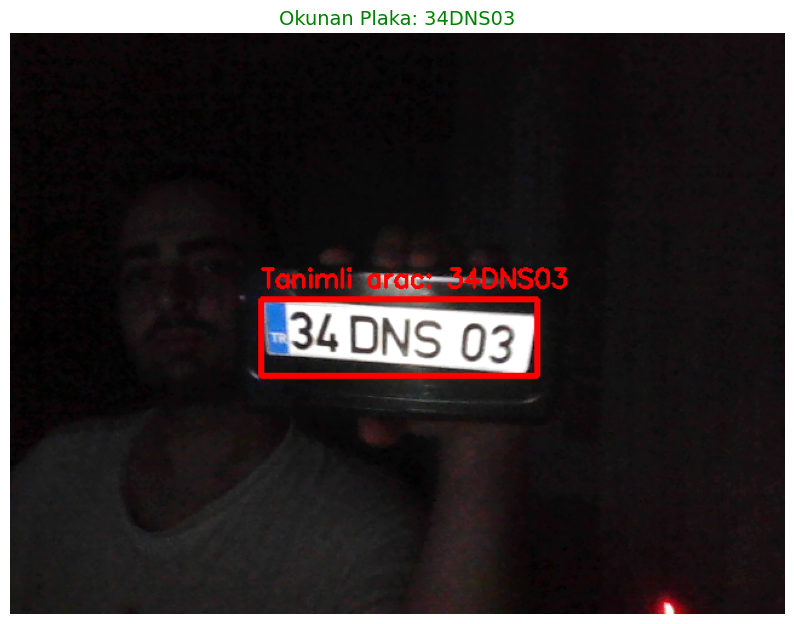

Süper! Plaka algılandı ve 'yakalanan_plaka.png' olarak klasörüne kaydedildi.


In [19]:
import cv2
import pytesseract
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time
import re

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

tanimli_plakalar=[
    "34DNS03",
    "34ABC123",
    "34XX341"
]

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)


sonuc_yazi="Plaka Bulunamadi"
sonuc_goruntu=None
okunan_plaka=""

time.sleep(2)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0) 
    edges = cv2.Canny(blur, 100, 200)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) 
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    plate = None 
    plate_box = None 

    for cnt in contours: 
        area = cv2.contourArea(cnt) 
        if area > 500:
            x, y, w, h = cv2.boundingRect(cnt) 
            ratio = w / float(h) 
            
            if 2 < ratio < 6 and w > 60 and h > 15:
                plate = gray[y:y+h, x:x+w]
                plate_box = (x, y, w, h)
                break
                
    temp_result = img_rgb.copy()

    if plate is not None:
        plate_big = cv2.resize(plate, None, fx=2, fy=2)
        _, plate_th = cv2.threshold(plate_big, 120, 255, cv2.THRESH_BINARY)
        plate_th = cv2.copyMakeBorder(
            plate_th, 10, 10, 10, 10,
            cv2.BORDER_CONSTANT, value=255
        )
        text = pytesseract.image_to_string(
            plate_th,
            config='--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
        )
        plaka_metin = re.sub(r'[^A-Z0-9]', '', text.upper())
        
        if plaka_metin != "":
            okunan_plaka = plaka_metin
            if plaka_metin in tanimli_plakalar:
                sonuc_yazi = f"Tanimli arac: {plaka_metin}"
            else:
                sonuc_yazi = f"Tanimsiz arac: {plaka_metin}"
                
            if plate_box is not None:
                x, y, w, h = plate_box

                cv2.rectangle(temp_result, (x, y), (x + w, y + h), (255, 0, 0), 3)
                cv2.putText(temp_result, sonuc_yazi, (x, max(30, y - 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
            
            sonuc_goruntu = temp_result
            break 
            
    cv2.imshow("Canli Plaka Tanima", frame)

    if cv2.waitKey(1) & 0xFF == 27: # ESC tuşu
        print("ESC ile cikildi.")
        break

cap.release()
cv2.destroyAllWindows()

if sonuc_goruntu is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(sonuc_goruntu)
    plt.title(f"Okunan Plaka: {okunan_plaka}", fontsize=14, color='green')
    plt.axis('off')
    plt.show()
    
    kayit_dosyasi = cv2.cvtColor(sonuc_goruntu, cv2.COLOR_RGB2BGR)
    cv2.imwrite("yakalanan_plaka.png", kayit_dosyasi)
    print(f"Süper! Plaka algılandı ve 'yakalanan_plaka.png' olarak klasörüne kaydedildi.")
else:
    print("Herhangi bir plaka okunamadan program kapatıldı.")